# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

Não é necessário realizar alterações nos tipos de dados, pois todos já estão adequados. Além disso, não será preciso fazer ajustes no conjunto de dados, uma vez que não há valores nulos no dataframe.

In [69]:
#seu código aqui
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


Foram identificadas quatro variáveis com presença de outliers: fixed acidity, residual sugar, free sulfur dioxide e total sulfur dioxide. Para a variável residual sugar, optou-se por ajustar os valores por meio da substituição pela mediana. Já nas demais variáveis, foi aplicado o método do IQR (Intervalo Interquartil) para tratamento dos outliers.	
A variavl Target(quality) está com os dados desbalanceados. O valor máximo é 8 e o minimo é 3.
As variáveis com maior correlação identificadas foram: fixed acidity e pH, apresentando uma correlação negativa de -0,68; fixed acidity e citric acid, com correlação positiva de 0,67; e fixed acidity com density, também com 0,67. Além disso, observou-se correlação negativa entre volatile acidity e citric acid (-0,55), bem como entre pH e citric acid (-0,54)

In [70]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


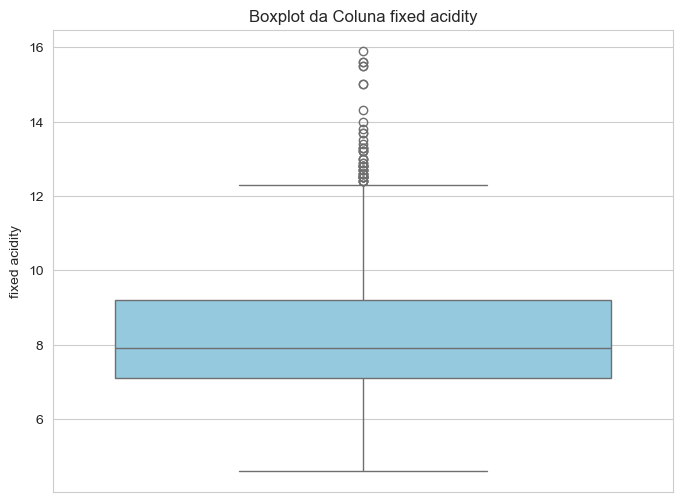

In [71]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='fixed acidity', color= 'skyblue')
plt.title('Boxplot da Coluna fixed acidity')
plt.ylabel('fixed acidity')
plt.show()


In [72]:
Q1 = df['fixed acidity'].quantile(0.25)
Q3 = df['fixed acidity'].quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

In [73]:
df = df[(df['fixed acidity'] >= limite_inferior) & 
        (df['fixed acidity'] <= limite_superior)]
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1550.000000,1550.000000,1550.000000,1550.000000,1550.00000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000
mean,8.162581,0.530294,0.261181,2.517645,0.08760,15.998065,46.766452,0.996633,3.318497,0.655761,10.418871,5.627742
std,1.513582,0.179731,0.188985,1.410528,0.04775,10.522594,33.207614,0.001786,0.150015,0.169768,1.060162,0.805968
min,4.600000,0.120000,0.000000,0.900000,0.01200,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.395000,0.090000,1.900000,0.07000,7.250000,22.000000,0.995570,3.220000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.07900,14.000000,38.000000,0.996680,3.320000,0.620000,10.150000,6.000000
75%,9.100000,0.640000,0.410000,2.600000,0.09000,22.000000,63.000000,0.997735,3.400000,0.720000,11.100000,6.000000
max,12.300000,1.580000,1.000000,15.500000,0.61100,72.000000,289.000000,1.003690,4.010000,2.000000,14.000000,8.000000


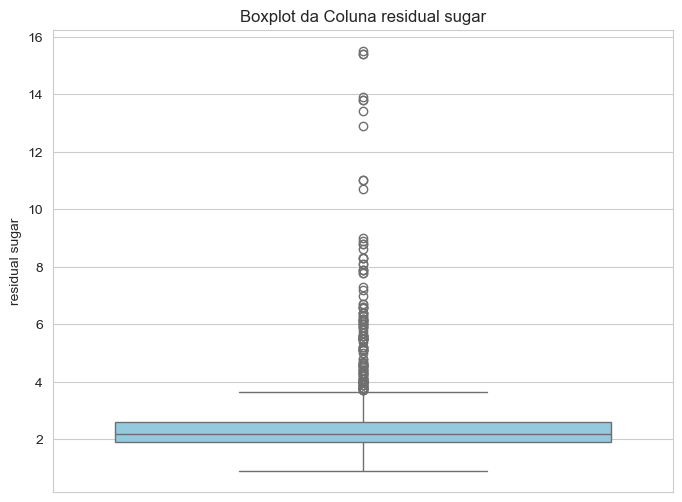

In [74]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='residual sugar', color= 'skyblue')
plt.title('Boxplot da Coluna residual sugar')
plt.ylabel('residual sugar')
plt.show()

In [75]:
(df['residual sugar'] > 3.35).mean() * 100

np.float64(10.774193548387096)

In [76]:
Q1_residual_sugar = df['residual sugar'].quantile(0.25)
Q3_residual_sugar = df['residual sugar'].quantile(0.75)

IQR_residual_sugar = Q3_residual_sugar - Q1_residual_sugar

limite_superior_residual_sugar = Q3_residual_sugar + 1.5 * IQR_residual_sugar
limite_inferior_residual_sugar = Q1_residual_sugar - 1.5 * IQR_residual_sugar

In [77]:
df.loc[df['residual sugar'] > limite_superior_residual_sugar, 'residual sugar'] =  df['residual sugar'].median()
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1550.000000,1550.000000,1550.000000,1550.000000,1550.00000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000
mean,8.162581,0.530294,0.261181,2.174387,0.08760,15.998065,46.766452,0.996633,3.318497,0.655761,10.418871,5.627742
std,1.513582,0.179731,0.188985,0.427842,0.04775,10.522594,33.207614,0.001786,0.150015,0.169768,1.060162,0.805968
min,4.600000,0.120000,0.000000,0.900000,0.01200,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.395000,0.090000,1.900000,0.07000,7.250000,22.000000,0.995570,3.220000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.07900,14.000000,38.000000,0.996680,3.320000,0.620000,10.150000,6.000000
75%,9.100000,0.640000,0.410000,2.400000,0.09000,22.000000,63.000000,0.997735,3.400000,0.720000,11.100000,6.000000
max,12.300000,1.580000,1.000000,3.650000,0.61100,72.000000,289.000000,1.003690,4.010000,2.000000,14.000000,8.000000


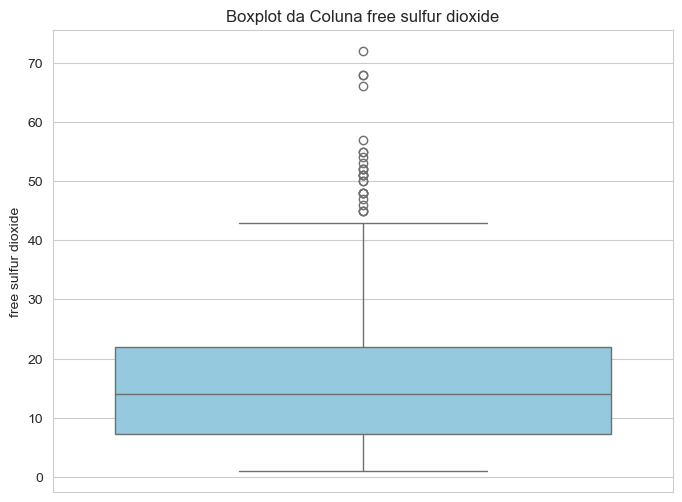

In [78]:
sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='free sulfur dioxide', color= 'skyblue')
plt.title('Boxplot da Coluna free sulfur dioxide')
plt.ylabel('free sulfur dioxide')
plt.show()

In [86]:
(df['free sulfur dioxide'] > 40).mean() * 100

np.float64(0.8185538881309686)

In [80]:
Q1_free_sulfur_dioxide = df['free sulfur dioxide'].quantile(0.25)
Q3_free_sulfur_dioxide = df['free sulfur dioxide'].quantile(0.75)

IQR_free_sulfur_dioxide = Q3_free_sulfur_dioxide - Q1_free_sulfur_dioxide

limite_superior_free_sulfur_dioxide = Q3_free_sulfur_dioxide + 1.5 * IQR_free_sulfur_dioxide
limite_inferior_free_sulfur_dioxide = Q1_free_sulfur_dioxide - 1.5 * IQR_free_sulfur_dioxide

In [81]:
df = df[(df['free sulfur dioxide'] >= limite_inferior_free_sulfur_dioxide) & 
        (df['free sulfur dioxide'] <= limite_superior_free_sulfur_dioxide)]
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000
mean,8.164150,0.530703,0.261615,2.173703,0.087057,15.344058,45.850952,0.996610,3.318352,0.655115,10.425772,5.629022
std,1.513948,0.179582,0.189171,0.429715,0.047409,9.337366,32.568468,0.001757,0.150293,0.169869,1.060151,0.807080
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.400000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995560,3.220000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996670,3.320000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.410000,2.400000,0.090000,21.000000,61.000000,0.997680,3.400000,0.720000,11.100000,6.000000
max,12.300000,1.580000,1.000000,3.650000,0.611000,43.000000,289.000000,1.002890,4.010000,2.000000,14.000000,8.000000


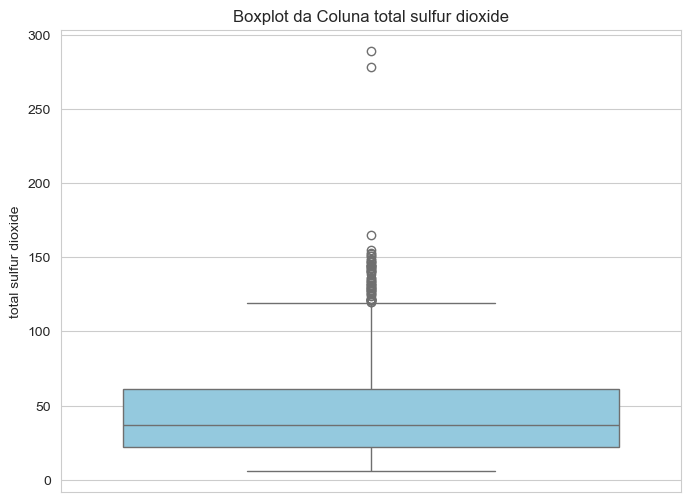

In [82]:

sns.set_style('whitegrid')

plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='total sulfur dioxide', color= 'skyblue')
plt.title('Boxplot da Coluna total sulfur dioxide')
plt.ylabel('total sulfur dioxide')
plt.show()

In [83]:
Q1_total_sulfur_dioxide = df['total sulfur dioxide'].quantile(0.25)
Q3_total_sulfur_dioxide = df['total sulfur dioxide'].quantile(0.75)

IQR_total_sulfur_dioxide = Q3_total_sulfur_dioxide - Q1_total_sulfur_dioxide

limite_superior_total_sulfur_dioxide = Q3_total_sulfur_dioxide + 1.5 * IQR_total_sulfur_dioxide
limite_inferior_total_sulfur_dioxide = Q1_total_sulfur_dioxide - 1.5 * IQR_total_sulfur_dioxide

In [84]:
(df['total sulfur dioxide'] > limite_superior_total_sulfur_dioxide).mean() * 100

np.float64(3.742613263296126)

In [85]:
df = df[(df['total sulfur dioxide'] >= limite_inferior_total_sulfur_dioxide) & 
        (df['total sulfur dioxide'] <= limite_superior_total_sulfur_dioxide)]
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000
mean,8.164939,0.529441,0.258342,2.172817,0.087176,14.823670,42.152797,0.996593,3.321842,0.652967,10.447851,5.647340
std,1.532995,0.179557,0.190372,0.433790,0.048202,9.041643,26.515419,0.001756,0.150143,0.157302,1.064171,0.812309
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.220000,0.550000,9.500000,5.000000
50%,7.800000,0.520000,0.240000,2.200000,0.079000,13.000000,36.000000,0.996600,3.320000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.410000,2.400000,0.090000,20.000000,57.750000,0.997600,3.410000,0.720000,11.100000,6.000000
max,12.300000,1.580000,1.000000,3.650000,0.611000,43.000000,119.000000,1.002890,4.010000,2.000000,14.000000,8.000000


In [87]:
# Verificando balanceamento da variavel target
df['quality'].value_counts()

quality
6    604
5    600
7    183
4     52
8     17
3     10
Name: count, dtype: int64

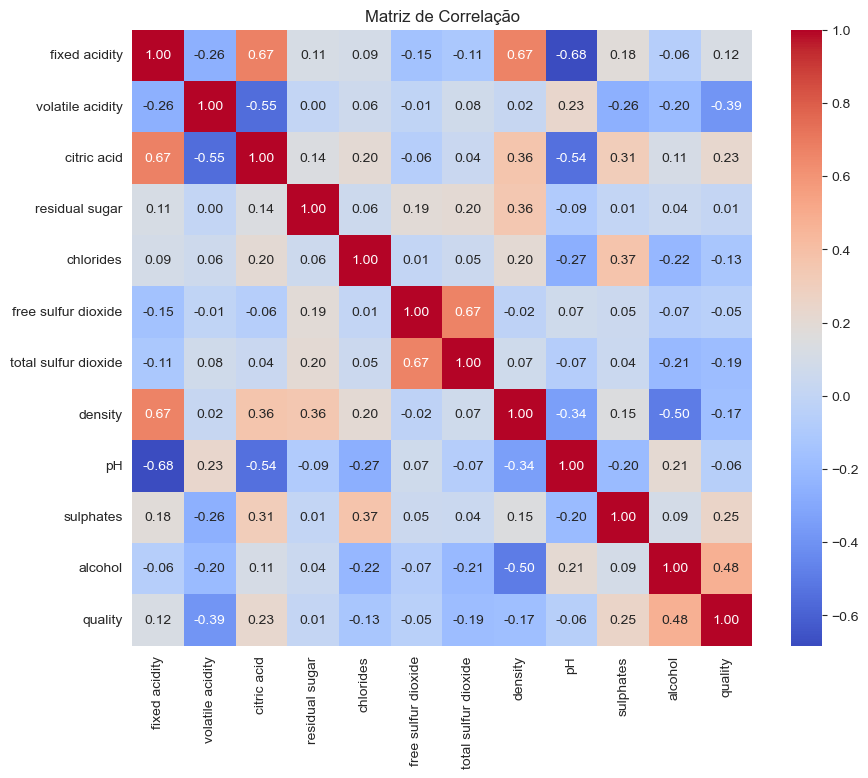

In [91]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

In [97]:
df_reduzido = df[['quality', 'sulphates', 'alcohol','citric acid', 'volatile acidity']]

# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


In [105]:
# seu código aqui
# Separando em X (variáveis de entrada) e Y (variável de saída)
X = df_reduzido.drop('quality', axis=1)  
Y = df_reduzido['quality']  

In [106]:
# Separando as bases em teste e treino
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


In [107]:
#seu código aqui
rf_model = RandomForestClassifier(random_state=42)

In [108]:
rf_model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [109]:
Y_pred = rf_model.predict(X_test)

# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


Ao analisar os resultados, o modelo apresentou uma acurácia de 0,60. As classes 3 e 8, que possuem menor quantidade de amostras, apresentaram precisão, recall e F1-score iguais a zero, indicando que o modelo não conseguiu prever nenhuma instância dessas classes. A classe 4 apresentou precisão de 100%, porém com recall de apenas 0,10 e F1-score de 0,18. Isso indica que, embora o modelo não cometa erros ao prever essa classe (alta precisão), ele identifica apenas uma pequena parte dos casos reais (baixo recall). A classe 5 obteve precisão de 66%, recall de 74% e F1-score de 0,70, demonstrando um desempenho relativamente equilibrado. Já a classe 6 apresentou precisão de 57%, recall de 55% e F1-score de 0,56, enquanto a classe 7 teve precisão de 50%, recall de 52% e F1-score de 0,51, ambos com desempenho moderado.
Dessa forma, fica evidente que o desbalanceamento dos dados impacta diretamente o modelo, que tende a performar melhor nas classes mais frequentes e apresenta dificuldade em aprender e prever corretamente as classes menos representadas.

In [110]:
#seu código aqui
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.60
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.10      0.18        10
           5       0.66      0.74      0.70       130
           6       0.57      0.55      0.56       132
           7       0.50      0.52      0.51        42
           8       0.00      0.00      0.00         5

    accuracy                           0.60       320
   macro avg       0.45      0.32      0.33       320
weighted avg       0.60      0.60      0.59       320

Matriz de Confusão:
 [[ 0  0  1  0  0  0]
 [ 0  1  5  4  0  0]
 [ 0  0 96 33  1  0]
 [ 0  0 43 73 16  0]
 [ 0  0  0 19 22  1]
 [ 0  0  0  0  5  0]]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# 6 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

A acurácia do modelo apresentou uma leve melhora, passando de 60% para 61%. As métricas das classes 3, 4, 5 e 8 permaneceram inalteradas, indicando que o modelo continua com dificuldades em aprender padrões dessas classes. Já as classes 6 e 7 apresentaram pequenas melhorias. Para a classe 6, a precisão aumentou de 57% para 58%, o recall de 55% para 56% e o F1-score de 56% para 57%. Na classe 7, a precisão passou de 50% para 52%, o recall de 52% para 55% e o F1-score de 51% para 53%.

Esses resultados refletem o impacto do ajuste de hiperparâmetros com o uso do RandomizedSearchCV utilizando a métrica f1_macro, que contribuiu para uma leve melhora no desempenho geral do modelo. No entanto, o desbalanceamento dos dados ainda influencia negativamente a capacidade do modelo de prever corretamente as classes menos representadas.

In [112]:
# seu código aqui
# Definir o espaço de busca dos hiperparâmetros

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [123]:
# Configurando o Randomized Search
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid,
                                   n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='f1_macro')


In [124]:
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,100
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [126]:
best_params = random_search.best_params_
print(f"Melhores Hiperparâmetros: {best_params}")

Melhores Hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}


In [127]:
# Treinando o modelo com os melhores hiperparâmetros encontrados acima
best_rf_model = random_search.best_estimator_
best_rf_model.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
Y_pred = best_rf_model.predict(X_test)

In [129]:
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.61
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.10      0.18        10
           5       0.66      0.74      0.70       130
           6       0.58      0.56      0.57       132
           7       0.52      0.55      0.53        42
           8       0.00      0.00      0.00         5

    accuracy                           0.61       320
   macro avg       0.46      0.32      0.33       320
weighted avg       0.61      0.61      0.59       320

Matriz de Confusão:
 [[ 0  0  1  0  0  0]
 [ 0  1  5  4  0  0]
 [ 0  0 96 33  1  0]
 [ 0  0 43 74 15  0]
 [ 0  0  1 17 23  1]
 [ 0  0  0  0  5  0]]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# 7 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

Com base nas análises e nos resultados obtidos, foi possível perceber algumas limitações no modelo, principalmente por causa do desbalanceamento das classes e da dificuldade em prever corretamente as classes com menos dados.
Uma das formas de melhorar isso é utilizando técnicas de oversampling, como o SMOTE, que cria novos exemplos para as classes minoritárias, ajudando o modelo a aprender melhor esses padrões. Isso pode melhorar métricas como recall e F1-score.
Também é possível ajustar o parâmetro class_weight nos modelos, dando mais importância para as classes menos frequentes. Assim, o modelo passa a “prestar mais atenção” nesses casos.
Outra alternativa é ajustar o threshold de decisão, principalmente quando o objetivo for aumentar o recall das classes minoritárias.
Por fim, pode-se simplificar o problema agrupando as classes em categorias maiores, como qualidade baixa, média e alta. Isso facilita o aprendizado do modelo e pode melhorar os resultados.
No geral, essas estratégias podem ajudar o modelo a ter um desempenho mais equilibrado, principalmente nas classes com menor quantidade de dados.